In [70]:
# Install sklearn extra package for K-Medoids
try:
    print("Installing sklearn extra package...\n")
    !pip install scikit-learn-extra -q
    !pip install pyclustering -q
    print(
        "scikit learn extra installed successfully."
    )
except Exception as installation_error:
    print(
        f"Installation Error: {installation_error}"
    )

Installing sklearn extra package...

scikit learn extra installed successfully.


In [71]:
# Environment Setup and Dataset Inspection
# Purpose:
# - Import required libraries
# - Load the credit dataset
# - Validate successful loading
# - Perform quick inspection of dataset structure

# import required libraries
try:
    import pandas as pd
    import numpy as np
    # visualization libraries
    import matplotlib.pyplot as plt
    import seaborn as sns
    # ML preprocessing and clustering libraries
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import LabelEncoder
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    # suppress non critical warning for cleaner notebook o/p
    import warnings
    warnings.filterwarnings(
      "ignore",
      category=FutureWarning
    )
except ImportError as import_error:
    print(f"Library import error: {import_error}")
except Exception as unexpected_import_error:
    print(f"Unexpected import error: {unexpected_import_error}")
# load dataset
try:
    # full qualified path to the uplaoded dataset
    dataset_file_path = "/content/train_data.csv"
    # read to dataframe
    credit_default_data = pd.read_csv(dataset_file_path)
    print("\nDataset loaded successfully")
except FileNotFoundError:
    print("Error: train_data.csv file not found. Check file location.")
except pd.errors.EmptyDataError:
    print("Error: Dataset file is empty.")
except pd.errors.ParserError:
    print("Error: Dataset could not be parsed. Verify CSV formatting.")
except Exception as dataset_loading_error:
    print(f"Dataset loading error: {dataset_loading_error}")

# intial dataset inspection to understand the dataset structure
#before preprocessing
try:
    # check if the dataframe exists before inspection
    if 'credit_default_data' in locals():
        print("\nDataset Shape:")
        print(credit_default_data.shape)
        print("\nFirst 5 Rows:")
        display(credit_default_data.head())
        print("\nColumn Names:")
        print(credit_default_data.columns.tolist())
        print("\nData Types:")
        display(credit_default_data.dtypes)
    else:
        print("Dataset not available for inspection.")
except Exception as inspection_error:
    print(f"Inspection error: {inspection_error}")


Dataset loaded successfully

Dataset Shape:
(153755, 122)

First 5 Rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,410704,0,Cash loans,F,N,Y,1,157500.0,900000.0,26446.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,381230,0,Cash loans,F,N,Y,1,90000.0,733176.0,21438.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
2,450177,0,Cash loans,F,Y,Y,0,189000.0,1795500.0,62541.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,332445,0,Cash loans,M,Y,N,0,175500.0,494550.0,45490.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,357429,0,Cash loans,F,Y,Y,0,270000.0,1724688.0,54283.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMON

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


In [72]:
# Dataset Quality Assessment and Initial Exploration
# Purpose:
# - Understand overall dataset quality
# - Check duplicates and missing values
# - Identify numerical and categorical features
# - Examine target balance for contextual understanding
# - Prepare for preprocessing before k-means clustering

try:
    print("Basic Dataset Information\n")
    # dataset dimensions
    total_rows, total_columns = credit_default_data.shape
    print(f"Total Rows    : {total_rows}")
    print(f"Total Columns : {total_columns}")
    # duplicate rows can create repeated patterns and may bias clustering
    duplicate_record_count = credit_default_data.duplicated().sum()
    print(f"\nDuplicate Rows : {duplicate_record_count}")
    # k-means works only with numerical inputs, hence categorical features
    # must be identified before encoding
    numerical_feature_columns = credit_default_data.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    categorical_feature_columns = credit_default_data.select_dtypes(
        include=["object"]
    ).columns.tolist()
    print("\nFeature Type Summary")
    print(f"Numerical Features   : {len(numerical_feature_columns)}")
    print(f"Categorical Features : {len(categorical_feature_columns)}")
    print("\nCategorical Feature Names:")
    print(categorical_feature_columns)
    # missing value assessment helps determine whether
    # features should be imputed or removed
    missing_value_count = credit_default_data.isnull().sum()
    columns_with_missing_values = missing_value_count[
        missing_value_count > 0
    ]
    print(
        f"\nColumns with Missing Values : "
        f"{len(columns_with_missing_values)}"
    )
    if len(columns_with_missing_values) > 0:
        missing_percentage = (
            columns_with_missing_values / total_rows
        ) * 100
        missing_value_report = pd.DataFrame({
            "Missing_Count": columns_with_missing_values,
            "Missing_Percentage": missing_percentage.round(2)
        }).sort_values(
            by="Missing_Percentage",
            ascending=False
        )
        print("\nTop 20 Columns with Missing Values:")
        display(missing_value_report.head(20))
        # columns with very high missingness often contribute to
        # limited information & might weaken clustering quality
        high_missing_features = missing_value_report[
            missing_value_report["Missing_Percentage"] > 50
        ]
        # store feature names separately so they can be reused in later cells
        high_missing_feature_names = high_missing_features.index.tolist()
        print("\nFeatures with More Than 50% Missing Values:")
        display(high_missing_features)
        print(
            f"\nHigh Missing Features (>50%) : "
            f"{len(high_missing_features)}"
        )
    # quick overview of datatype composition in the dataset
    print("\nFeature Datatype Distribution")
    print(credit_default_data.dtypes.value_counts())
    # TARGET is not used during clustering because k-means is unsupervised,
    # however class balance still provides useful business context
    print("\nTarget Variable Distribution")
    target_distribution_count = (
        credit_default_data["TARGET"]
        .value_counts()
    )
    target_distribution_percentage = (
        credit_default_data["TARGET"]
        .value_counts(normalize=True) * 100
    )
    target_distribution_summary = pd.DataFrame({
        "Count": target_distribution_count,
        "Percentage": target_distribution_percentage.round(2)
    })
    display(target_distribution_summary)
except KeyError as missing_column_error:
    print(f"Column Error: {missing_column_error}")
except Exception as unexpected_error:
    print(f"Unexpected Error: {unexpected_error}")

Basic Dataset Information

Total Rows    : 153755
Total Columns : 122

Duplicate Rows : 0

Feature Type Summary
Numerical Features   : 106
Categorical Features : 16

Categorical Feature Names:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Columns with Missing Values : 66

Top 20 Columns with Missing Values:


,Missing_Count,Missing_Percentage
COMMONAREA_MODE,107523,69.93
COMMONAREA_AVG,107523,69.93
COMMONAREA_MEDI,107523,69.93
NONLIVINGAPARTMENTS_MEDI,106918,69.54
NONLIVINGAPARTMENTS_MODE,106918,69.54
NONLIVINGAPARTMENTS_AVG,106918,69.54
LIVINGAPARTMENTS_MEDI,105193,68.42
LIVINGAPARTMENTS_MODE,105193,68.42
LIVINGAPARTMENTS_AVG,105193,68.42
FONDKAPREMONT_MODE,105177,68.41



Features with More Than 50% Missing Values:


,Missing_Count,Missing_Percentage
COMMONAREA_MODE,107523,69.93
COMMONAREA_AVG,107523,69.93
COMMONAREA_MEDI,107523,69.93
NONLIVINGAPARTMENTS_MEDI,106918,69.54
NONLIVINGAPARTMENTS_MODE,106918,69.54
NONLIVINGAPARTMENTS_AVG,106918,69.54
LIVINGAPARTMENTS_MEDI,105193,68.42
LIVINGAPARTMENTS_MODE,105193,68.42
LIVINGAPARTMENTS_AVG,105193,68.42
FONDKAPREMONT_MODE,105177,68.41



High Missing Features (>50%) : 41

Feature Datatype Distribution
float64    65
int64      41
object     16
Name: count, dtype: int64

Target Variable Distribution


,Count,Percentage
TARGET,,
0,141343,91.93
1,12412,8.07


In [73]:
# Feature Cleaning and Missing Value Treatment
# Purpose:
# - Remove features with excessive missing values
# - Retain more reliable variables for clustering
# - Recreate numerical and categorical feature lists
# - Prepare cleaned dataset for imputation and encoding

try:
    print("Feature Cleaning and Missing Value Treatment\n")
    # columns with more than 50% missing data might provide
    # limited information and can weaken clustering quality
    print(
        f"Features Removed (>50% Missing) : "
        f"{len(high_missing_feature_names)}"
    )
    # create cleaned dataframe after removing high missing features
    cleaned_credit_data = credit_default_data.drop(
        columns=high_missing_feature_names
    )
    print(
        f"\nRemaining Features : "
        f"{cleaned_credit_data.shape[1]}"
    )
    # recreate feature groups after cleaning
    cleaned_numerical_features = cleaned_credit_data.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    cleaned_categorical_features = cleaned_credit_data.select_dtypes(
        include=["object"]
    ).columns.tolist()
    print("\nUpdated Feature Summary")
    print(
        f"Numerical Features   : "
        f"{len(cleaned_numerical_features)}"
    )
    print(
        f"Categorical Features : "
        f"{len(cleaned_categorical_features)}"
    )
    print("\nCleaned Dataset Shape:")
    print(cleaned_credit_data.shape)
except NameError as variable_error:
    print(f"Variable Error: {variable_error}")
except Exception as cleaning_error:
    print(f"Cleaning Error: {cleaning_error}")

Feature Cleaning and Missing Value Treatment

Features Removed (>50% Missing) : 41

Remaining Features : 81

Updated Feature Summary
Numerical Features   : 68
Categorical Features : 13

Cleaned Dataset Shape:
(153755, 81)


In [74]:
# Missing Value Imputation
# Purpose:
# - Handle remaining missing values after feature removal
# - Impute numerical variables using median values
# - Impute categorical variables using mode values
# - Prepare complete dataset for encoding and scaling
try:
    print("Missing Value Imputation\n")
    # create a copy to preserve cleaned dataset
    imputed_credit_data = cleaned_credit_data.copy()
    # identify remaining numerical and categorical columns
    numerical_columns = imputed_credit_data.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
    categorical_columns = imputed_credit_data.select_dtypes(
        include=["object"]
    ).columns.tolist()
    # exclude TARGET since clustering is unsupervised
    if "TARGET" in numerical_columns:
        numerical_columns.remove("TARGET")
    # track missing values before imputation
    total_missing_before = (
        imputed_credit_data.isnull().sum().sum()
    )
    print(
        f"Total Missing Values Before Imputation : "
        f"{total_missing_before}"
    )
    # median imputation for numerical features
    # median is more robust for financial variables
    # because income and credit data are often skewed
    for numerical_feature in numerical_columns:
        if (
            imputed_credit_data[
                numerical_feature
            ].isnull().sum() > 0
        ):
            median_value = (
                imputed_credit_data[
                    numerical_feature
                ].median()
            )
            imputed_credit_data[
                numerical_feature
            ] = (
                imputed_credit_data[
                    numerical_feature
                ].fillna(median_value)
            )
    print(
        f"Numerical Features Imputed : "
        f"{len(numerical_columns)}"
    )
    # mode imputation for categorical variables
    # preserves the most commonly occurring category
    for categorical_feature in categorical_columns:
        if (
            imputed_credit_data[
                categorical_feature
            ].isnull().sum() > 0
        ):
            mode_value = (
                imputed_credit_data[
                    categorical_feature
                ].mode()[0]
            )
            imputed_credit_data[
                categorical_feature
            ] = (
                imputed_credit_data[
                    categorical_feature
                ].fillna(mode_value)
            )
    print(
        f"Categorical Features Imputed : "
        f"{len(categorical_columns)}"
    )
    # verify that imputation completed successfully
    total_missing_after = (
        imputed_credit_data.isnull().sum().sum()
    )
    print(
        f"\nTotal Missing Values After Imputation : "
        f"{total_missing_after}"
    )
    if total_missing_after == 0:
        print(
            "Imputation completed successfully. "
            "No missing values remain."
        )
    else:
        print(
            "Warning: Some missing values still remain."
        )
except KeyError as missing_column_error:
    print(
        f"Column Error: {missing_column_error}"
    )
except Exception as imputation_error:
    print(
        f"Imputation Error: {imputation_error}"
    )

Missing Value Imputation

Total Missing Values Before Imputation : 808641
Numerical Features Imputed : 67
Categorical Features Imputed : 13

Total Missing Values After Imputation : 0
Imputation completed successfully. No missing values remain.


In [75]:
# Categorical Feature Encoding
# Purpose:
# - Convert categorical variables into numerical format
# - Apply label encoding to categorical features
# - Prepare fully numeric dataset for scaling and clustering
try:
    print("Categorical Feature Encoding\n")
    # create copy to preserve imputed dataset
    encoded_credit_data = imputed_credit_data.copy()
    # identify categorical columns
    categorical_columns = encoded_credit_data.select_dtypes(
        include=["object"]
    ).columns.tolist()
    print(
        f"Categorical Features Identified : "
        f"{len(categorical_columns)}"
    )
    # store encoders for possible interpretation later
    label_encoder_dictionary = {}
    # apply label encoding feature-by-feature
    for categorical_feature in categorical_columns:
        feature_label_encoder = LabelEncoder()
        encoded_credit_data[categorical_feature] = (
            feature_label_encoder.fit_transform(
                encoded_credit_data[categorical_feature]
            )
        )
        label_encoder_dictionary[
            categorical_feature
        ] = feature_label_encoder
    print(
        f"Encoded Features : "
        f"{len(categorical_columns)}"
    )
    # verify dataset is fully numeric
    remaining_object_columns = encoded_credit_data.select_dtypes(
        include=["object"]
    ).columns.tolist()
    print(
        f"\nRemaining Object Columns : "
        f"{len(remaining_object_columns)}"
    )
    if len(remaining_object_columns) == 0:
        print(
            "Encoding completed successfully. "
            "Dataset is fully numerical."
        )
    else:
        print(
            "Warning: Some categorical variables remain."
        )
except KeyError as missing_column_error:
    print(f"Column Error: {missing_column_error}")
except Exception as encoding_error:
    print(f"Encoding Error: {encoding_error}")

Categorical Feature Encoding

Categorical Features Identified : 13
Encoded Features : 13

Remaining Object Columns : 0
Encoding completed successfully. Dataset is fully numerical.


### Categorical Encoding Note

Label encoding was applied to convert categorical variables into numerical form while maintaining computational efficiency and avoiding high dimensional sparsity that one hot encoding would introduce for high cardinality variables.

This approach may introduce ordinal assumptions among categories that can influence Euclidean distance calculations. However, considering the large dataset size and the number of categorical levels present in features such as organization and occupation categories, label encoding was considered a practical preprocessing choice for this clustering analysis.

Future work may evaluate alternative approaches such as one hot encoding for lower cardinality variables or mixed type clustering techniques.

In [76]:
# Feature Scaling for K-Means
# Purpose:
# - Remove non-clustering columns
# - Standardize numerical values
# - Prepare feature matrix for distance-based clustering
try:
    print("Feature Scaling for K-Means\n")
    # create copy to preserve encoded dataset
    clustering_feature_data = (
        encoded_credit_data.copy()
    )
    removed_columns = []
    # remove identifier and target variables
    columns_to_remove = []
    if "SK_ID_CURR" in clustering_feature_data.columns:
        columns_to_remove.append(
            "SK_ID_CURR"
        )
    if "TARGET" in clustering_feature_data.columns:
        columns_to_remove.append(
            "TARGET"
        )
    if len(columns_to_remove) > 0:
        removed_columns.extend(
            columns_to_remove
        )
        clustering_feature_data = (
            clustering_feature_data.drop(
                columns=columns_to_remove
            )
        )
    print("\nColumns Removed From Clustering:")
    print(removed_columns)
    print(
        f"\nClustering Features Used : "
        f"{clustering_feature_data.shape[1]}"
    )
    # standard scaling
    feature_scaler = StandardScaler()
    scaled_feature_matrix = (
        feature_scaler.fit_transform(
            clustering_feature_data
        )
    )
    print(
        "\nScaling completed successfully."
    )
    print(
        "\nScaled Feature Matrix Shape:"
    )
    print(
        scaled_feature_matrix.shape
    )
except Exception as scaling_error:
    print(
        f"Scaling Error: {scaling_error}"
    )

Feature Scaling for K-Means


Columns Removed From Clustering:
['SK_ID_CURR', 'TARGET']

Clustering Features Used : 79

Scaling completed successfully.

Scaled Feature Matrix Shape:
(153755, 79)


K-Means Experimentation and Cluster Evaluation

Running K-Means for Multiple k Values...

Evaluating k = 3
Inertia          : 10806173.37
Silhouette Score : 0.0581

Evaluating k = 5
Inertia          : 10130740.06
Silhouette Score : 0.0755

Evaluating k = 7
Inertia          : 9758351.81
Silhouette Score : 0.0642

K-Means Evaluation Summary:


,k_value,Inertia,Silhouette_Score
0,3,1.080617e+07,0.058064
1,5,1.013074e+07,0.075525
2,7,9.758352e+06,0.064243


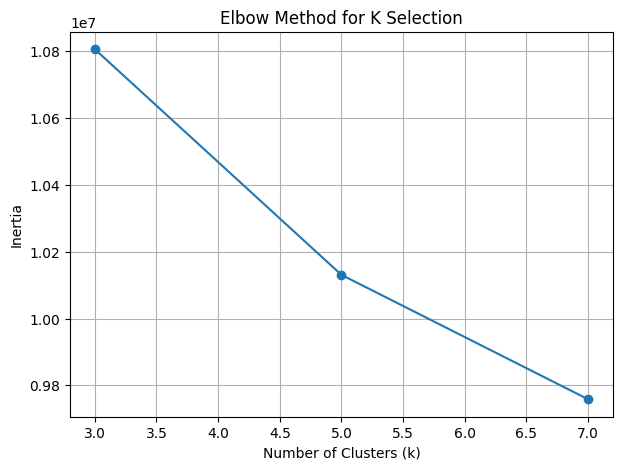

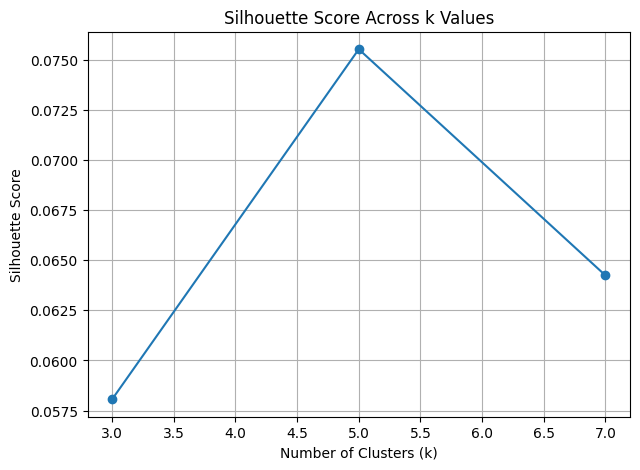

In [77]:
# K-Means Experimentation with Multiple k Values
# Purpose:
# - Experiment with multiple k values
# - Evaluate clustering quality using inertia and silhouette score
# - Visualize elbow and silhouette trends
# - Support final k selection for clustering
try:
    print("K-Means Experimentation and Cluster Evaluation\n")
    # candidate cluster values
    candidate_k_values = [3, 5, 7]
    # containers for evaluation metrics
    inertia_scores = []
    silhouette_scores = []
    print("Running K-Means for Multiple k Values...\n")
    for current_k in candidate_k_values:
        print(f"Evaluating k = {current_k}")
        # initialize k-means
        kmeans_model = KMeans(
            n_clusters=current_k,
            random_state=42,
            n_init=10
        )
        # fit and predict
        cluster_labels = kmeans_model.fit_predict(
            scaled_feature_matrix
        )
        # inertia
        current_inertia = kmeans_model.inertia_
        inertia_scores.append(current_inertia)
        # sampled silhouette score for faster execution
        current_silhouette_score = silhouette_score(
            scaled_feature_matrix,
            cluster_labels,
            sample_size=10000,
            random_state=42
        )
        silhouette_scores.append(
            current_silhouette_score
        )
        print(
            f"Inertia          : "
            f"{current_inertia:.2f}"
        )
        print(
            f"Silhouette Score : "
            f"{current_silhouette_score:.4f}\n"
        )
    # summary table
    clustering_evaluation_summary = pd.DataFrame({
        "k_value": candidate_k_values,
        "Inertia": inertia_scores,
        "Silhouette_Score": silhouette_scores
    })
    print("K-Means Evaluation Summary:")
    display(clustering_evaluation_summary)
    # elbow plot
    plt.figure(figsize=(7,5))
    plt.plot(
        candidate_k_values,
        inertia_scores,
        marker="o"
    )
    plt.title("Elbow Method for K Selection")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()
    # silhouette plot
    plt.figure(figsize=(7,5))
    plt.plot(
        candidate_k_values,
        silhouette_scores,
        marker="o"
    )
    plt.title("Silhouette Score Across k Values")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()
except ValueError as model_error:
    print(f"Model Error: {model_error}")
except Exception as clustering_error:
    print(f"Clustering Error: {clustering_error}")

In [78]:
# Final K-Means Model Creation
# Purpose:
# - Train final k-means model using selected k
# - Assign cluster labels to customers
# - Examine cluster membership distribution
# - Prepare dataset for cluster profiling and interpretation
try:
    print("Final K-Means Model Creation\n")
    # final k selected using elbow and silhouette analysis
    final_k_value = 5
    print(
        f"Selected Number of Clusters (k) : "
        f"{final_k_value}"
    )
    # initialize final model
    final_kmeans_model = KMeans(
        n_clusters=final_k_value,
        random_state=42,
        n_init=10
    )
    # generate cluster labels
    final_cluster_labels = final_kmeans_model.fit_predict(
        scaled_feature_matrix
    )
    # attach cluster labels to dataset
    clustered_credit_data = encoded_credit_data.copy()
    clustered_credit_data["Cluster_Label"] = (
        final_cluster_labels
    )
    print("\nCluster labels assigned successfully.")
    # cluster membership distribution
    cluster_size_summary = (
        clustered_credit_data["Cluster_Label"]
        .value_counts()
        .sort_index()
    )
    cluster_percentage_summary = (
        clustered_credit_data["Cluster_Label"]
        .value_counts(normalize=True)
        .sort_index() * 100
    )
    cluster_distribution_report = pd.DataFrame({
        "Customer_Count": cluster_size_summary,
        "Percentage": cluster_percentage_summary.round(2)
    })
    print("\nCluster Distribution:")
    display(cluster_distribution_report)
except ValueError as model_error:
    print(f"Model Error: {model_error}")
except Exception as final_model_error:
    print(f"Final Model Error: {final_model_error}")

Final K-Means Model Creation

Selected Number of Clusters (k) : 5

Cluster labels assigned successfully.

Cluster Distribution:


,Customer_Count,Percentage
Cluster_Label,,
0,96801,62.96
1,22095,14.37
2,7761,5.05
3,315,0.20
4,26783,17.42


In [79]:
# Distance Metric Experimentation Using Sampled K-Medoids
# Purpose:
# - Compare Euclidean and Manhattan distance behavior
# - Compare clustering quality using silhouette score
# - Use sampling for computational feasibility
try:
    from pyclustering.cluster.kmedoids import kmedoids
    from pyclustering.utils.metric import (
        distance_metric,
        type_metric
    )
    import numpy as np
    print("Distance Metric Experimentation\n")
    # sample subset for computational feasibility
    sample_size = 5000
    np.random.seed(42)
    sample_indices = np.random.choice(
        scaled_feature_matrix.shape[0],
        sample_size,
        replace=False
    )
    sampled_scaled_data = (
        scaled_feature_matrix[sample_indices]
    )
    sampled_array = np.array(
        sampled_scaled_data
    )
    print(
        f"Sample Size Used : "
        f"{sample_size}"
    )
    # initial medoids
    initial_medoids = [
        0,
        100,
        500,
        1000,
        2000
    ]
    # Manhattan metric
    manhattan_metric = distance_metric(
        type_metric.MANHATTAN
    )
    # K-Medoids model
    kmedoids_model = kmedoids(
        sampled_array,
        initial_medoids,
        metric=manhattan_metric
    )
    kmedoids_model.process()
    clusters = (
        kmedoids_model.get_clusters()
    )
    # convert cluster structure to labels
    kmedoids_labels = np.zeros(
        sampled_array.shape[0],
        dtype=int
    )
    for cluster_id, cluster_points in enumerate(
        clusters
    ):
        kmedoids_labels[
            cluster_points
        ] = cluster_id

    # Manhattan silhouette
    kmedoids_silhouette_score = silhouette_score(
        sampled_array,
        kmedoids_labels,
        sample_size=3000,
        random_state=42
    )
    # Euclidean K-Means score from previous cell
    kmeans_silhouette_score = max(silhouette_scores)
    print(
        f"K-Medoids (Manhattan) Silhouette Score : "
        f"{kmedoids_silhouette_score:.4f}"
    )
    print(
        f"K-Means (Euclidean) Silhouette Score   : "
        f"{kmeans_silhouette_score:.4f}"
    )
    # simple comparison
    if kmeans_silhouette_score > kmedoids_silhouette_score:
        print(
            "\nEuclidean K-Means produced "
            "better cluster separation."
        )
    else:
        print(
            "\nManhattan K-Medoids produced "
            "better cluster separation."
        )
except Exception as metric_error:
    print(
        f"Distance Metric Error: {metric_error}"
    )

Distance Metric Experimentation

Sample Size Used : 5000
K-Medoids (Manhattan) Silhouette Score : 0.0376
K-Means (Euclidean) Silhouette Score   : 0.0755

Euclidean K-Means produced better cluster separation.


## Distance Metric Comparison and Model Selection

To explore the influence of distance metrics on clustering behavior, an additional experiment was conducted using K-Medoids with Manhattan distance and compared against the final K-Means model using Euclidean distance.

The comparison showed:

| Clustering Method | Distance Metric | Silhouette Score |
|------------------|----------------|------------------|
| K-Means | Euclidean | 0.0755 |
| K-Medoids | Manhattan | 0.0376 |

The Euclidean distance K-Means model achieved a higher silhouette score, indicating stronger cluster cohesion and better separation between customer groups. Manhattan distance clustering produced weaker separation on the sampled dataset.

Based on these findings, Euclidean distance K-Means was retained as the final clustering model because it demonstrated superior clustering quality for the given credit risk dataset.

PCA Cluster Visualization



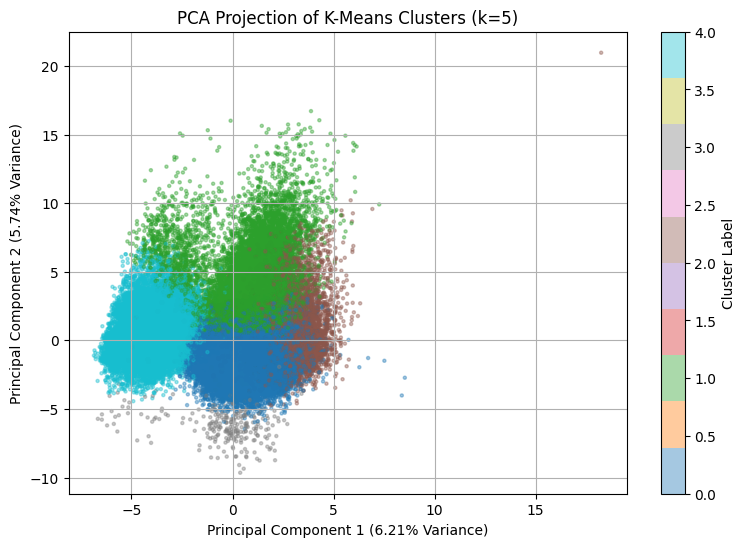

In [80]:
# PCA-Based Cluster Visualization
# Purpose:
# - Visualize cluster separation
# - Reduce high dimensional data into 2 components
# - Provide view of cluster structure
try:
    from sklearn.decomposition import PCA
    print("PCA Cluster Visualization\n")
    pca_model = PCA(
        n_components=2,
        random_state=42
    )
    pca_coordinates = (
        pca_model.fit_transform(
            scaled_feature_matrix
        )
    )
    plt.figure(figsize=(9,6))
    scatter_plot = plt.scatter(
        pca_coordinates[:,0],
        pca_coordinates[:,1],
        c=final_cluster_labels,
        cmap="tab10",
        alpha=0.4,
        s=5
    )
    plt.colorbar(
        scatter_plot,
        label="Cluster Label"
    )
    plt.title(
        "PCA Projection of K-Means Clusters (k=5)"
    )
    plt.xlabel(
        f"Principal Component 1 "
        f"({pca_model.explained_variance_ratio_[0]*100:.2f}% Variance)"
    )
    plt.ylabel(
        f"Principal Component 2 "
        f"({pca_model.explained_variance_ratio_[1]*100:.2f}% Variance)"
    )
    plt.grid(True)
    plt.show()
except Exception as pca_error:
    print(
        f"PCA Visualization Error: {pca_error}"
    )

In [81]:
# Cluster Profiling and Feature Interpretation
# Purpose:
# - Compare cluster characteristics
# - Identify influential financial and demographic features
# - Prepare business interpretation of clusters
try:
    print("Cluster Profiling and Interpretation\n")
    # selected interpretable features
    profiling_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "CNT_CHILDREN",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "TARGET"
    ]
    # keep only features available
    available_profiling_features = [
        feature_name
        for feature_name in profiling_features
        if feature_name in clustered_credit_data.columns
    ]
    # cluster mean summary
    cluster_profile_summary = (
        clustered_credit_data
        .groupby("Cluster_Label")[
            available_profiling_features
        ]
        .mean()
        .round(2)
    )
    print(
        "Average Feature Values Across Clusters:"
    )
    display(cluster_profile_summary)
except KeyError as missing_feature_error:
    print(
        f"Feature Error: {missing_feature_error}"
    )
except Exception as profiling_error:
    print(
        f"Profiling Error: {profiling_error}"
    )

Cluster Profiling and Interpretation

Average Feature Values Across Clusters:


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_2,EXT_SOURCE_3,TARGET
Cluster_Label,,,,,,,,,,
0,163434.69,584972.62,26661.75,523777.51,0.52,-14720.19,-2330.30,0.50,0.51,0.09
1,211436.80,707022.63,31556.21,642689.15,0.42,-15335.14,14750.75,0.58,0.51,0.06
2,246149.63,687029.77,31871.61,620763.69,0.44,-14226.82,-1632.20,0.54,0.48,0.09
3,160108.89,616712.44,25837.33,554292.46,0.33,-16023.16,45377.65,0.53,0.52,0.11
4,133353.22,534191.89,23542.64,480128.40,0.04,-21836.76,362124.30,0.50,0.56,0.05


Normalized Cluster Heatmap



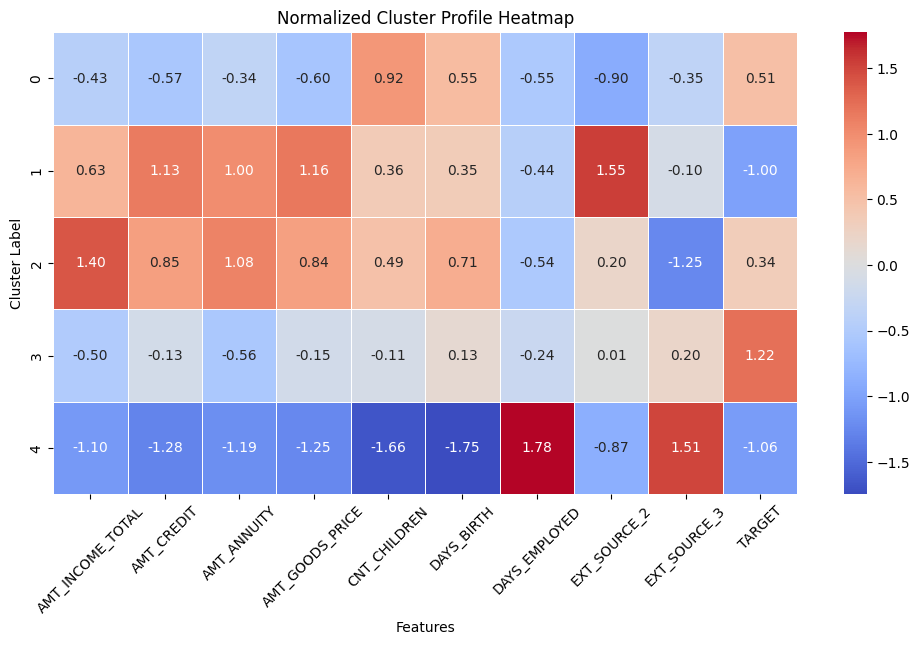

Heatmap generated successfully


In [82]:
# Normalized Cluster Heatmap for Feature Interpretation
# Purpose:
# - Standardize cluster mean values
# - Visualize relative feature differences across clusters
# - Identify influential features driving segmentation
# - Strengthen cluster interpretation and presentation
try:
    print("Normalized Cluster Heatmap\n")
    # features selected for cluster interpretation
    heatmap_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AMT_GOODS_PRICE",
        "CNT_CHILDREN",
        "DAYS_BIRTH",
        "DAYS_EMPLOYED",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
        "TARGET"
    ]
    # retain only available columns
    available_heatmap_features = [
        feature_name
        for feature_name in heatmap_features
        if feature_name in clustered_credit_data.columns
    ]
    # calculate cluster wise averages
    cluster_heatmap_data = (
        clustered_credit_data
        .groupby("Cluster_Label")[
            available_heatmap_features
        ]
        .mean()
    )
    # normalize cluster means to compare patterns
    normalized_cluster_heatmap = (
        cluster_heatmap_data
        - cluster_heatmap_data.mean()
    ) / cluster_heatmap_data.std()
    # create heatmap
    plt.figure(figsize=(12,6))
    sns.heatmap(
        normalized_cluster_heatmap,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5
    )
    plt.title(
        "Normalized Cluster Profile Heatmap"
    )
    plt.ylabel("Cluster Label")
    plt.xlabel("Features")
    plt.xticks(rotation=45)
    plt.show()
    print(
        "Heatmap generated successfully"
    )
except Exception as heatmap_error:
    print(
        f"Heatmap Error: {heatmap_error}"
    )

Cluster Size Visualization



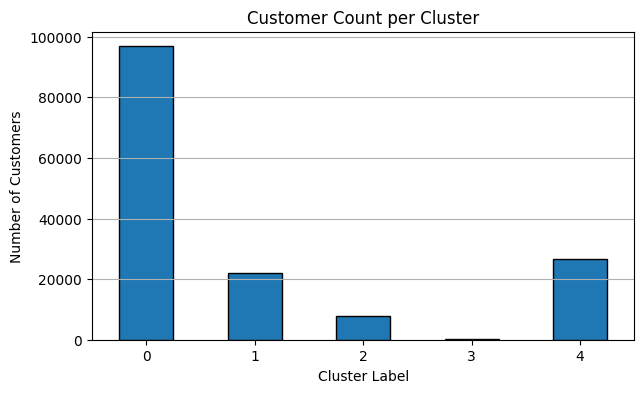

In [83]:
# Cluster Size Visualization
# Purpose:
# - Visualize customer distribution across clusters
# - Identify dominant and minority customer segments
try:
    print(
        "Cluster Size Visualization\n"
    )
    cluster_size_summary = (
        clustered_credit_data[
            "Cluster_Label"
        ]
        .value_counts()
        .sort_index()
    )
    plt.figure(
        figsize=(7, 4)
    )
    cluster_size_summary.plot(
        kind="bar",
        edgecolor="black"
    )
    plt.title(
        "Customer Count per Cluster"
    )
    plt.xlabel(
        "Cluster Label"
    )
    plt.ylabel(
        "Number of Customers"
    )
    plt.xticks(
        rotation=0
    )
    plt.grid(
        axis="y"
    )
    plt.show()

except Exception as visualization_error:

    print(
        f"Visualization Error: "
        f"{visualization_error}"
    )

# Final Cluster Interpretation and Business Insights

## 1. Why was k = 5 selected?

Three k values (3, 5, and 7) were evaluated using inertia and silhouette score.

- **k = 3** → Silhouette Score = 0.0581  
- **k = 5** → Silhouette Score = 0.0755  
- **k = 7** → Silhouette Score = 0.0642  

Although inertia continued to decrease as k increased, **k = 5** produced the highest silhouette score. This indicates better cluster separation and stronger internal cohesion. In addition, k = 5 provided a practical balance between model quality and interpretability. Larger values of k may reduce interpretability and create unnecessary segmentation complexity.

---

## 2. Transformations Applied to the Dataset

Several preprocessing steps were performed before clustering:

1. Features with more than **50% missing values** were removed to reduce noise and improve reliability.
2. Numerical missing values were imputed using **median values**.
3. Categorical missing values were imputed using **mode values**.
4. Categorical variables were converted into numerical form using **Label Encoding**.
5. Feature scaling was performed using **StandardScaler** because k-means relies on Euclidean distance and is sensitive to differences in feature magnitude.
6. Identifier and target columns (**SK_ID_CURR** and **TARGET**) were excluded from clustering.

These preprocessing steps ensured that all variables were suitable for distance based clustering and helped improve clustering quality.

---

## 3. Important Features Influencing Cluster Formation

The following variables appeared to be influential in creating the clusters:

- **AMT_INCOME_TOTAL**  
- **AMT_CREDIT**  
- **AMT_GOODS_PRICE**  
- **AMT_ANNUITY**  
- **DAYS_BIRTH**  
- **DAYS_EMPLOYED**  
- **EXT_SOURCE_2**  
- **EXT_SOURCE_3**

The normalized cluster heatmap showed meaningful variation across these variables, suggesting that financial capacity, borrowing exposure, age, employment history, and external risk scores played important roles in customer segmentation.

---

## 4. Cluster Level Business Interpretation

### Cluster 0 - Mainstream Borrowers

This was the largest customer segment and showed moderate income, credit exposure, and repayment risk. These borrowers appear to represent the institution's typical customer population and form the baseline lending segment.

### Cluster 1 - Financially Strong Borrowers

This cluster showed higher credit amounts and lower default tendency. These customers appear financially stronger and may be suitable candidates for premium lending products, larger credit limits, and relationship expansion strategies.

### Cluster 2 - High Income but Higher Exposure Customers

Customers in this segment had the highest income levels but also carried substantial borrowing commitments. Their earning capacity is strong, although repayment risk remains moderate because of higher financial exposure.

### Cluster 3 - Specialized Higher Risk Segment

This was a very small cluster with elevated default tendency and unusual employment characteristics. The segment may represent atypical or specialized borrowers and could require additional monitoring or stricter underwriting practices.

### Cluster 4 - Conservative and Lower Risk Borrowers

This segment showed lower borrowing levels and the lowest default tendency. These borrowers appear more conservative and financially stable, making them potential candidates for retention and long term relationship strategies.

---

## 5. Business Relevance of the Clusters

The clustering analysis suggests that borrowers are not homogeneous and can be separated into meaningful financial and risk based segments.

Potential business implications include:

- Lower risk groups may support **premium lending and retention strategies**.
- Higher risk groups may benefit from **stricter underwriting and monitoring**.
- Credit exposure and repayment behavior vary considerably across customer segments.
- Customer segmentation can support **better lending decisions, portfolio management, and risk control**.

Overall, k-means clustering successfully identified distinct customer profiles that may help financial institutions improve credit risk management and develop more targeted lending strategies.